In [89]:
from pathlib import Path
from topopt.monitoring import MetricTracker
import pandas as pd
import re
import numpy as np

In [90]:
OUTPUTS_DIR = Path(".")

metrics_by_run = {}

for run_dir in OUTPUTS_DIR.iterdir():
    if not run_dir.is_dir():
        continue

    metrics_path = run_dir / "metrics_log.npz"
    if not metrics_path.exists():
        continue

    name = run_dir.name
    if "neural_field" not in name:
        continue

    key = name.split("neural_field", 1)[1]
    key = key.lstrip("_-")

    # Load metrics
    metrics = MetricTracker.load(npz_path=metrics_path)

    metrics_by_run[key] = metrics

In [91]:
OUTPUTS_DIR = Path(".")

def parse(path: Path) -> pd.DataFrame:
    return pd.read_csv(
        path,
        sep=",",
        index_col=0
    )


# ----------------------------------------
# Main aggregation
# ----------------------------------------

eval_results_by_run = {}

for run_dir in OUTPUTS_DIR.iterdir():
    if not run_dir.is_dir():
        continue

    log_path = run_dir / "model_evaluation.csv"
    if not log_path.exists():
        continue

    if "neural_field" not in run_dir.name:
        continue

    # Key: everything after "neural_field"
    key = run_dir.name.split("neural_field", 1)[1].lstrip("_-")

    try:
        df = parse(log_path)
    except Exception as e:
        print(f"[WARN] Failed to parse {log_path}: {e}")
        continue
    eval_results_by_run[key] = df

print(len(eval_results_by_run.keys()))

16


In [92]:
cols_to_drop = ["rho_actual", "rho_target", "rho_error", "penalty", "omega", "scale"]

for key, df in eval_results_by_run.items():
    # extract layers/channels from key, e.g. "train_siren_different_layer_6_channel_256"
    layer_match = re.search(r"(?:different_)?layer_(\d+)", key)
    channel_match = re.search(r"channel_(\d+)", key)
    layers = int(layer_match.group(1)) if layer_match else None
    channels = int(channel_match.group(1)) if channel_match else None

    tmp = df.copy()
    tmp["layers"] = layers
    tmp["channels"] = channels

    # drop unwanted columns (ignore in case some are missing)
    tmp.drop(columns=cols_to_drop, inplace=True, errors="ignore")

    print(key)
    print(tmp)


train_siren_different_layer_6_channel_128
         compliance  layers  channels
model                                
model_5     74.9119       6       128
model_6     75.1172       6       128
model_2     75.2829       6       128
model_0     75.3148       6       128
model_7     75.5110       6       128
model_3     75.6688       6       128
model_4     75.7781       6       128
model_1     75.7900       6       128
train_siren_different_layer_5_channel_128
         compliance  layers  channels
model                                
model_2     74.6755       5       128
model_4     74.7741       5       128
model_1     74.8826       5       128
model_6     74.9970       5       128
model_5     75.0724       5       128
model_0     75.2283       5       128
model_7     75.4056       5       128
model_3     75.4453       5       128
train_siren_different_layer_4_channel_64
         compliance  layers  channels
model                                
model_0     76.3844       4        64
m

In [93]:
import pandas as pd

# Average compliance over the 8 runs (models) per experiment key
rows = []
for key, df in eval_results_by_run.items():
    layer_match = re.search(r"(?:different_)?layer_(\d+)", key)
    channel_match = re.search(r"channel_(\d+)", key)
    layers = int(layer_match.group(1)) if layer_match else None
    channels = int(channel_match.group(1)) if channel_match else None

    rows.append(
        {
            "run_key": key,
            "layers": layers,
            "channels": channels,
            "compliance_mean": float(df["compliance"].mean()),
        }
    )

avg_compliance = (
    pd.DataFrame(rows)
    .dropna(subset=["layers", "channels"])
    .astype({"layers": int, "channels": int})
    .sort_values(["layers", "channels"], ignore_index=True)
)

avg_compliance

,run_key,layers,channels,compliance_mean
0,train_siren_different_layer_3_channel_32,3,32,110.348588
1,train_siren_different_layer_3_channel_64,3,64,84.558425
2,train_siren_different_layer_3_channel_128,3,128,78.939863
3,train_siren_different_layer_3_channel_256,3,256,76.506425
4,train_siren_different_layer_4_channel_32,4,32,86.349263
5,train_siren_different_layer_4_channel_64,4,64,78.212750
6,train_siren_different_layer_4_channel_128,4,128,75.611787
7,train_siren_different_layer_4_channel_256,4,256,75.206288
8,train_siren_different_layer_5_channel_32,5,32,83.700275
9,train_siren_different_layer_5_channel_64,5,64,76.570075


/var/folders/lq/92gdbsr10818q962z0cmxfg40000gn/T/ipykernel_6963/4240819191.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_data.applymap(lambda v: "" if pd.isna(v) else f"{v:.2f}")


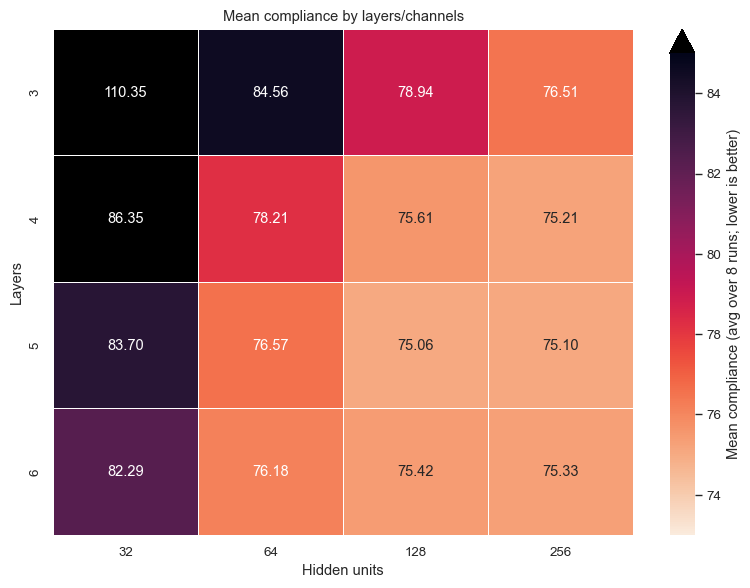

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap: layers (y) vs channels (x), color = mean compliance
heatmap_data = (
    avg_compliance
    .pivot(index="layers", columns="channels", values="compliance_mean")
    .sort_index()
)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

# Colormap choices (all support *_r for reverse): "mako", "rocket", "flare", "cividis", "cubehelix"
# Reversed palette so: lower (better) = lighter, higher (worse) = darker.
cmap_name = "rocket_r"
cmap = sns.color_palette(cmap_name, as_cmap=True)
cmap.set_over("black")
cmap.set_bad("#f0f0f0")

# Focus the color scale on the main region (75–79)
vmin, vmax = 73, 85

# Cell annotations: always show numeric values
annot = heatmap_data.applymap(lambda v: "" if pd.isna(v) else f"{v:.2f}")

sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    heatmap_data,
    annot=annot,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Mean compliance (avg over 8 runs; lower is better)",
        "extend": "max",
    },
)
ax.set_xlabel("Hidden units")
ax.set_ylabel("Layers")
ax.set_title(f"Mean compliance by layers/channels")

plt.tight_layout()
plt.savefig("compliance_heatmap_layers_channels.pdf", bbox_inches="tight")
plt.show()

In [95]:
# One row per (layers, channels): mean compliance over the 8 runs
avg_compliance

,run_key,layers,channels,compliance_mean
0,train_siren_different_layer_3_channel_32,3,32,110.348588
1,train_siren_different_layer_3_channel_64,3,64,84.558425
2,train_siren_different_layer_3_channel_128,3,128,78.939863
3,train_siren_different_layer_3_channel_256,3,256,76.506425
4,train_siren_different_layer_4_channel_32,4,32,86.349263
5,train_siren_different_layer_4_channel_64,4,64,78.212750
6,train_siren_different_layer_4_channel_128,4,128,75.611787
7,train_siren_different_layer_4_channel_256,4,256,75.206288
8,train_siren_different_layer_5_channel_32,5,32,83.700275
9,train_siren_different_layer_5_channel_64,5,64,76.570075


In [96]:
# Best settings (lowest mean compliance)
avg_compliance.nsmallest(5, "compliance_mean")[["layers", "channels", "compliance_mean", "run_key"]]

,layers,channels,compliance_mean,run_key
10,5,128,75.060100,train_siren_different_layer_5_channel_128
11,5,256,75.098075,train_siren_different_layer_5_channel_256
7,4,256,75.206288,train_siren_different_layer_4_channel_256
15,6,256,75.325013,train_siren_different_layer_6_channel_256
14,6,128,75.421838,train_siren_different_layer_6_channel_128


In [97]:
from pathlib import Path

import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt


def parse_timing_summary(log_path: Path) -> dict[str, float]:
    lines = log_path.read_text().splitlines()
    try:
        start = lines.index("Timing summary")
    except ValueError:
        return {}

    out: dict[str, float] = {}
    for line in lines[start + 1 :]:
        m = re.match(r"^\s*(?P<label>[^:]+?)\s*:\s*(?P<sec>\d+(?:\.\d+)?)s", line)
        if not m:
            continue

        label = (
            m.group("label")
            .strip()
            .lower()
            .replace("/", "_")
            .replace(" ", "_")
            .replace("-", "_")
        )
        out[f"time_{label}_s"] = float(m.group("sec"))
    return out


def siren_param_count(
    *,
    num_channels_in: int,
    num_channels_out: int,
    num_layers: int,
    num_latent_channels: int,
) -> int:
    # matches the layout used in the project: (in, latent x (L-1), out)
    channels = [num_channels_in] + [num_latent_channels] * (num_layers - 1) + [num_channels_out]
    total = 0
    for in_c, out_c in zip(channels[:-1], channels[1:]):
        total += in_c * out_c  # weights
        total += out_c  # bias
    return int(total)

# Special data point (only appears in `other/`)
SPECIAL_RUN_DIR = Path("other/02-07_17-17-59_neural_field_train_siren_different_layer_3_channel_512")
SPECIAL_RUN_KEY = None
special_rows = []
special_eval_path = SPECIAL_RUN_DIR / "model_evaluation.csv"
if special_eval_path.exists():
    special_key = SPECIAL_RUN_DIR.name.split("neural_field", 1)[1].lstrip("_-")
    SPECIAL_RUN_KEY = special_key
    df_special = pd.read_csv(special_eval_path, sep=",", index_col=0)
    layer_match = re.search(r"(?:different_)?layer_(\d+)", special_key)
    channel_match = re.search(r"channel_(\d+)", special_key)
    layers = int(layer_match.group(1)) if layer_match else None
    channels = int(channel_match.group(1)) if channel_match else None
    special_rows.append(
        {
            "run_key": special_key,
            "layers": layers,
            "channels": channels,
            "compliance_mean": float(df_special["compliance"].mean()),
        }
    )
else:
    print(f"[WARN] Missing special eval file: {special_eval_path}")

special_avg_compliance = pd.DataFrame(special_rows)
avg_compliance_for_plots = (
    pd.concat([avg_compliance, special_avg_compliance], ignore_index=True)
    .dropna(subset=["layers", "channels"])
    .astype({"layers": int, "channels": int})
    .sort_values(["layers", "channels"], ignore_index=True)
)


# Parse timing logs next to this notebook
timing_rows = []
logs_root = Path("terminal_output")

for run_key in avg_compliance_for_plots["run_key"]:
    log_path = logs_root / run_key / "output.log"
    if not log_path.exists():
        continue
    timing_rows.append({"run_key": run_key, **parse_timing_summary(log_path)})

timings_by_run = pd.DataFrame(timing_rows)

# Merge timings + compute parameter count and time-per-parameter
avg_with_time = avg_compliance_for_plots.merge(timings_by_run, on="run_key", how="left")
avg_with_time["param_count"] = avg_with_time.apply(
    lambda r: siren_param_count(
        num_channels_in=2,
        num_channels_out=1,
        num_layers=int(r["layers"]),
        num_latent_channels=int(r["channels"]),
    ),
    axis=1,
)


avg_with_time

,run_key,layers,channels,compliance_mean,time_wall_total_s,time_hot_optimise_s,time_compile_first_s,time_other_s,param_count
0,train_siren_different_layer_3_channel_32,3,32,110.348588,201.685,72.685,123.922,5.077,1185
1,train_siren_different_layer_3_channel_64,3,64,84.558425,202.645,73.651,123.902,5.092,4417
2,train_siren_different_layer_3_channel_128,3,128,78.939863,209.658,79.367,125.207,5.084,17025
3,train_siren_different_layer_3_channel_256,3,256,76.506425,224.442,94.656,124.745,5.041,66817
4,train_siren_different_layer_3_channel_512,3,512,75.616263,278.817,151.904,121.795,5.118,264705
5,train_siren_different_layer_4_channel_32,4,32,86.349263,208.008,78.088,124.904,5.017,2241
6,train_siren_different_layer_4_channel_64,4,64,78.212750,209.732,79.879,124.749,5.105,8577
7,train_siren_different_layer_4_channel_128,4,128,75.611787,290.623,160.464,125.103,5.056,33537
8,train_siren_different_layer_4_channel_256,4,256,75.206288,337.608,206.455,126.035,5.118,132609
9,train_siren_different_layer_5_channel_32,5,32,83.700275,212.571,83.807,123.764,5.000,3297


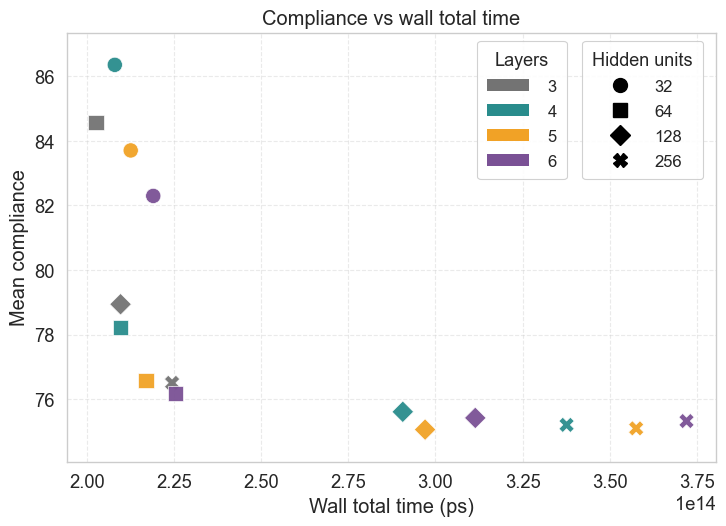

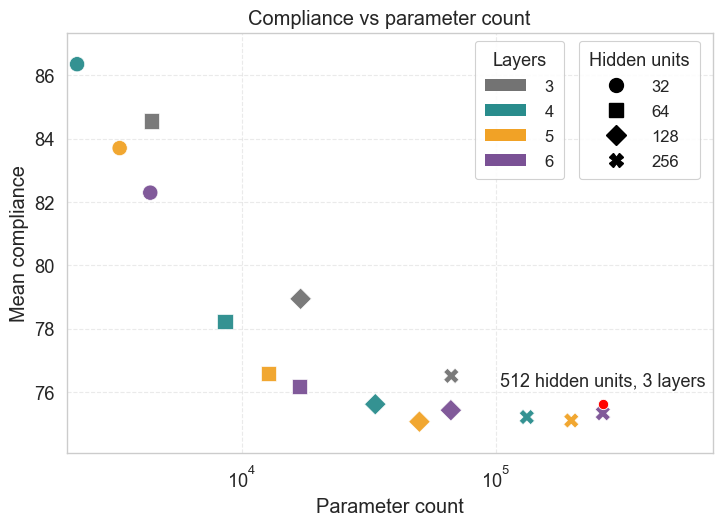

In [98]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

from itertools import cycle
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# More contrasty colors for layers + rectangular legend patches
layer_order = sorted(avg_with_time["layers"].dropna().unique())
channel_order = sorted(avg_with_time.loc[avg_with_time["channels"] != 512, "channels"].dropna().unique())
# Palette for the scatter plots (layers as hue)
# Mapping layers -> colors; adjust the 4th color as you like.
layer_palette = {
    3: "#737373",
    4: "#298c8c",
    5: "#f1a226",
    6: "#7a5195",
}
layer_palette = {l: layer_palette.get(l, "#7a5195") for l in layer_order}

marker_cycle = cycle(["o", "s", "D", "X", "^", "v", "P"])
channel_markers = {ch: next(marker_cycle) for ch in channel_order}


def add_layer_channel_legends(ax):
    # Remove seaborn's automatic legend
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

    layer_handles = [
        Patch(facecolor=layer_palette[l], edgecolor="none", label=f"{l}")
        for l in layer_order
    ]
    channel_handles = [
        Line2D(
            [0],
            [0],
            marker=channel_markers[ch],
            color="black",
            linestyle="None",
            markersize=10,
            label=f"{ch}",
        )
        for ch in channel_order
    ]

    # --- Layers legend (left) ---
    leg_layers = ax.legend(
        handles=layer_handles,
        title="Layers",
        loc="upper right",
        bbox_to_anchor=(0.77, 0.98),
        fontsize=12,
        title_fontsize=13,
        frameon=True,
        framealpha=0.9,
        borderaxespad=0,
        labelspacing=0.6,
        borderpad=0.6,
        handletextpad=1.1,   # space between icon and text
        handlelength=2.5
    )
    ax.add_artist(leg_layers)

    # --- Hidden-units legend (right) ---
    ax.legend(
        handles=channel_handles,
        title="Hidden units",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        fontsize=12,
        title_fontsize=13,
        frameon=True,
        framealpha=0.9,
        borderaxespad=0,
        labelspacing=0.6,
        borderpad=0.6,
        handletextpad=1.1,   # space between icon and text
    )


def apply_outlier_filter(df, *, threshold=100.0):
    outliers = df[df["compliance_mean"] > threshold].copy()
    kept = df[df["compliance_mean"] <= threshold].copy()
    return kept, outliers

# 1) Compliance vs wall total time (ps)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
avg_with_time["time_wall_total_ps"] = avg_with_time["time_wall_total_s"] * 1e12
plot_df, outliers = apply_outlier_filter(avg_with_time, threshold=100.0)
base_plot_df = plot_df[plot_df["channels"] != 512].copy()
sns.scatterplot(
    data=base_plot_df,
    x="time_wall_total_ps",
    y="compliance_mean",
    hue="layers",
    style="channels",
    hue_order=layer_order,
    style_order=channel_order,
    palette=layer_palette,
    markers=channel_markers,
    s=120,
    alpha=0.95,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)
add_layer_channel_legends(ax)

ax.set_ylim(plot_df["compliance_mean"].min() - 1, plot_df["compliance_mean"].max() + 1)
ax.set_xlabel("Wall total time (ps)")
ax.set_ylabel("Mean compliance")
ax.set_title("Compliance vs wall total time")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("compliance_vs_wall_total_time_ps.pdf", bbox_inches="tight")
plt.show()

# 2) Compliance vs parameter count
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(
    data=base_plot_df,
    x="param_count",
    y="compliance_mean",
    hue="layers",
    style="channels",
    hue_order=layer_order,
    style_order=channel_order,
    palette=layer_palette,
    markers=channel_markers,
    s=120,
    alpha=0.95,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

# Special point: 512 hidden units, 3 layers (not part of hidden-unit legend)
if SPECIAL_RUN_KEY is not None:
    special_pt = plot_df[plot_df["run_key"] == SPECIAL_RUN_KEY]
    if len(special_pt) == 1:
        x = float(special_pt["param_count"].iloc[0])
        y = float(special_pt["compliance_mean"].iloc[0])
        ax.scatter(
            [x],
            [y],
            marker="o",
            s=55,
            color="red",
            edgecolors="white",
            linewidths=0.6,
            zorder=6,
        )
        ax.annotate(
            "512 hidden units, 3 layers",
            (x, y),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            va="bottom",
            fontsize=13,
        )
add_layer_channel_legends(ax)

ax.set_ylim(plot_df["compliance_mean"].min() - 1, plot_df["compliance_mean"].max() + 1)
ax.set_xscale("log")
x_min = float(plot_df["param_count"].min())
x_max = float(plot_df["param_count"].max())
ax.set_xlim(x_min / 1.1, x_max * 2.7)
ax.set_xlabel("Parameter count")
ax.set_ylabel("Mean compliance")
ax.set_title("Compliance vs parameter count")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("compliance_vs_param_count.pdf", bbox_inches="tight")
plt.show()



In [99]:
# Count how often the CuDSS message appears per output.log
from pathlib import Path

import pandas as pd

needle = "cudss batch: CSR pattern pointers changed"
rows = []

logs_root = Path("terminal_output")
for run_dir in sorted(logs_root.iterdir()):
    if not run_dir.is_dir():
        continue
    log_path = run_dir / "output.log"
    if not log_path.exists():
        continue

    text = log_path.read_text(errors="ignore")
    rows.append(
        {
            "run_key": run_dir.name,
            "csr_pattern_pointers_changed_count": text.count(needle),
        }
    )

cudss_counts = pd.DataFrame(rows)
cudss_counts = cudss_counts.merge(
    avg_compliance[["run_key", "layers", "channels"]],
    on="run_key",
    how="left",
)
cudss_counts = cudss_counts.sort_values(
    ["csr_pattern_pointers_changed_count", "layers", "channels"],
    ascending=[False, True, True],
    ignore_index=True,
)

cudss_counts

,run_key,csr_pattern_pointers_changed_count,layers,channels
0,train_siren_different_layer_4_channel_256,396,4.0,256.0
1,train_siren_different_layer_5_channel_256,378,5.0,256.0
2,train_siren_different_layer_6_channel_256,344,6.0,256.0
3,train_siren_different_layer_4_channel_128,322,4.0,128.0
4,train_siren_different_layer_6_channel_128,312,6.0,128.0
5,train_siren_different_layer_5_channel_128,294,5.0,128.0
6,train_siren_different_layer_3_channel_32,0,3.0,32.0
7,train_siren_different_layer_3_channel_64,0,3.0,64.0
8,train_siren_different_layer_3_channel_128,0,3.0,128.0
9,train_siren_different_layer_3_channel_256,0,3.0,256.0


/var/folders/lq/92gdbsr10818q962z0cmxfg40000gn/T/ipykernel_6963/1467956141.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


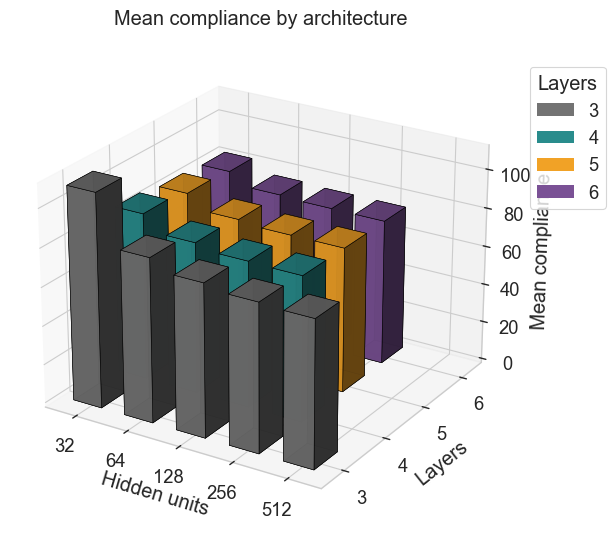

In [100]:
from mpl_toolkits.mplot3d import Axes3D

# 3D bar chart: architecture choice (layers/channels) vs mean compliance
fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection="3d")

bar_df = avg_with_time.sort_values(["layers", "channels"]).copy()
x_labels = sorted(bar_df["channels"].unique())
y_labels = sorted(bar_df["layers"].unique())
x_pos_map = {ch: i for i, ch in enumerate(x_labels)}
y_pos_map = {ly: i for i, ly in enumerate(y_labels)}

x = bar_df["channels"].map(x_pos_map).to_numpy(dtype=float)
y = bar_df["layers"].map(y_pos_map).to_numpy(dtype=float)
z = np.zeros(len(bar_df))
dx = np.full(len(bar_df), 0.55)
dy = np.full(len(bar_df), 0.55)
dz = bar_df["compliance_mean"].to_numpy(dtype=float)
colors = bar_df["layers"].map(layer_palette).tolist()

ax.bar3d(x - dx / 2, y - dy / 2, z, dx, dy, dz, color=colors, edgecolor="black", linewidth=0.4, alpha=0.95, shade=True)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels([str(v) for v in x_labels])
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels([str(v) for v in y_labels])
ax.set_xlabel("Hidden units")
ax.set_ylabel("Layers")
ax.set_zlabel("Mean compliance")
ax.set_title("Mean compliance by architecture")
ax.view_init(elev=24, azim=-58)

layer_handles = [
    Patch(facecolor=layer_palette[layer], edgecolor="none", label=f"{layer}")
    for layer in y_labels
]
ax.legend(handles=layer_handles, title="Layers", loc="upper left", bbox_to_anchor=(1.02, 0.95), frameon=True)

plt.tight_layout()
plt.savefig("compliance_3d_bar_layers_channels.pdf", bbox_inches="tight")
plt.show()


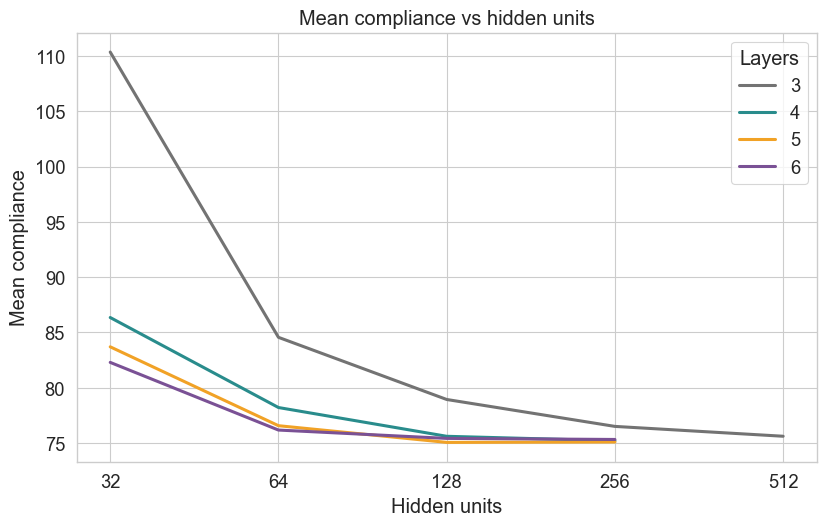

In [101]:
# Line plot for the paper: width on x-axis, mean compliance on y-axis, one line per depth
line_df = avg_compliance_for_plots.copy()
line_df = line_df.sort_values(["layers", "channels"])

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.lineplot(
    data=line_df,
    x="channels",
    y="compliance_mean",
    hue="layers",
    linewidth=2.2,
    markersize=8,
    palette=layer_palette,
    ax=ax,
)

ax.set_title("Mean compliance vs hidden units")
ax.set_xlabel("Hidden units")
ax.set_ylabel("Mean compliance")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(line_df["channels"].unique()))
ax.set_xticklabels([str(v) for v in sorted(line_df["channels"].unique())])
ax.legend(title="Layers")

plt.tight_layout()
plt.savefig("compliance_vs_hidden_units_by_layers.pdf", bbox_inches="tight")
plt.show()


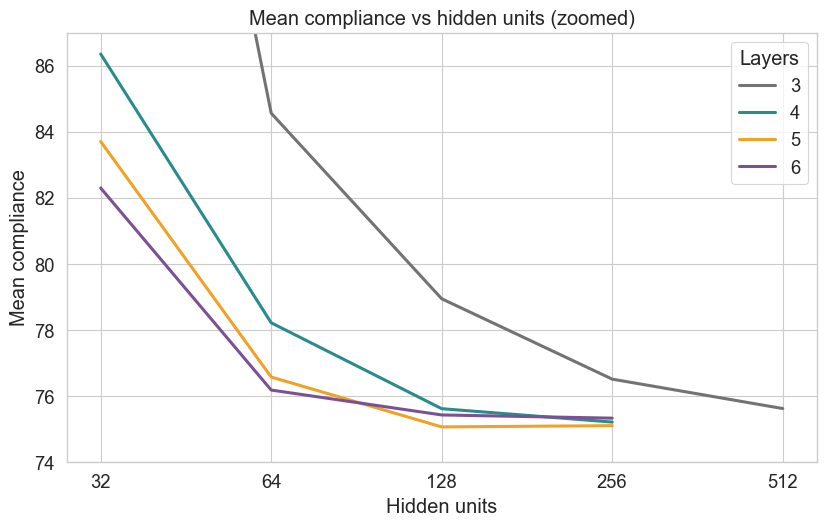

In [102]:
# Zoomed line plot for the paper: focus on the competitive compliance range
zoom_df = avg_compliance_for_plots.copy()
zoom_df = zoom_df.sort_values(["layers", "channels"])

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.lineplot(
    data=zoom_df,
    x="channels",
    y="compliance_mean",
    hue="layers",
    linewidth=2.2,
    palette=layer_palette,
    ax=ax,
)

ax.set_title("Mean compliance vs hidden units (zoomed)")
ax.set_xlabel("Hidden units")
ax.set_ylabel("Mean compliance")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(zoom_df["channels"].unique()))
ax.set_xticklabels([str(v) for v in sorted(zoom_df["channels"].unique())])
ax.set_ylim(74, 87)
ax.legend(title="Layers")

plt.tight_layout()
plt.savefig("compliance_vs_hidden_units_by_layers_zoomed.pdf", bbox_inches="tight")
plt.show()
